# Orchestrator-Worker

## Definition of Orchestrator-Worker

In the **orchestrator-workers workflow**, a central LLM dynamically breaks down a task into smaller subtasks, delegates them to worker LLMs, and then synthesizes their results into a final output.

**When to use this workflow:** This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

## How Orchestrator-Worker Works with LangGraph

1. **Receive the Input:** The workflow receives a complex task from the user.

2. **Orchestrate the Task:** The orchestrator LLM analyzes the input and dynamically breaks it into smaller subtasks.

3. **Delegate to Workers:** The generated subtasks are distributed to multiple worker nodes. Each worker independently processes its assigned subtask.

4. **Collect Worker Results:** The results generated by the workers are passed back to the orchestrator or a synthesizer node.

5. **Synthesize the Results:** The synthesizer combines the individual worker outputs into a coherent final response.

6. **Generate the Final Output:** The synthesized result is returned as the final output.

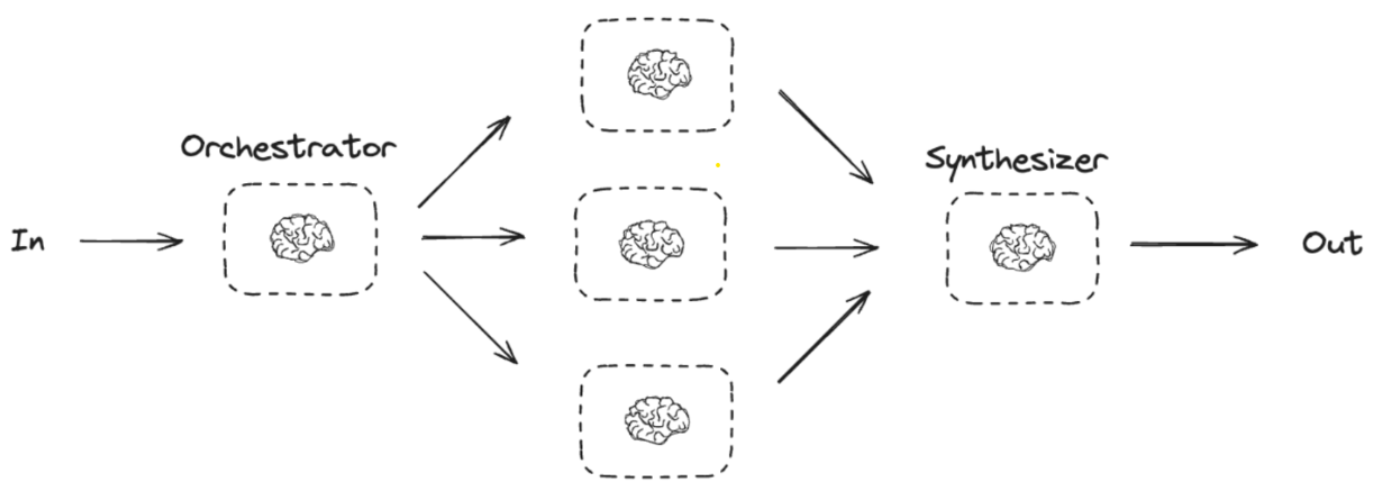

## Benefits of Orchestrator-Worker

- **Dynamic Task Decomposition:** The orchestrator can determine subtasks based on the input rather than relying on predefined tasks.

- **Handles Complex Tasks:** Suitable for problems that require multiple different operations or areas of work.

- **Flexible Workflow:** The number and type of worker tasks can change depending on the requirements of each input.

- **Parallel Execution:** Independent worker tasks can potentially be executed in parallel, improving efficiency.

- **Specialized Workers:** Different workers can be designed to handle different types of subtasks.

- **Result Synthesis:** A synthesizer can combine multiple worker outputs into a single coherent final result.

## Orchestrator-Worker vs Parallelization

- **Parallelization:** Subtasks are predefined and can run independently.

- **Orchestrator-Worker:** Subtasks are dynamically determined by the orchestrator based on the input.

## Problem Statement

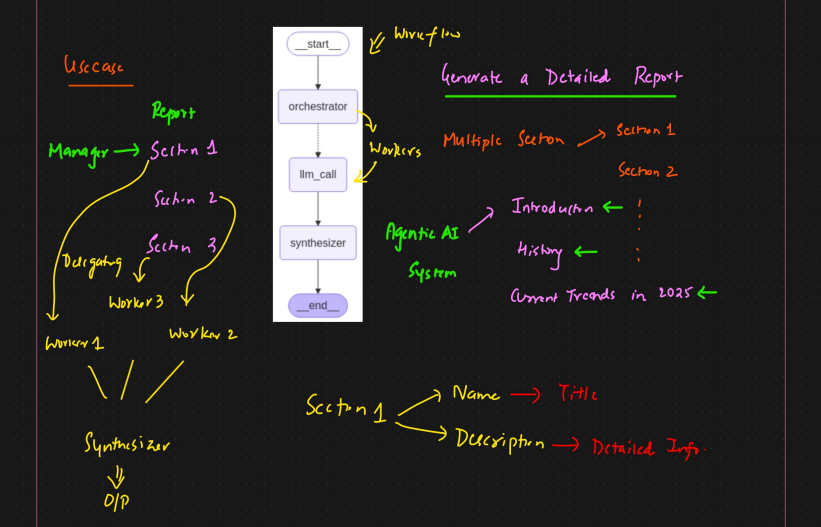

## Solution

### Setting Up the Chat Model

In [21]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    max_tokens=500
)

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.019853779, 'completion_tokens_details': None, 'prompt_time': 0.000678671, 'prompt_tokens_details': None, 'queue_time': 0.047122448, 'total_time': 0.02053245}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_4560dae850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fd12-db52-7df1-a30d-13ff9e5c2046-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

### Creating the Report Planning Schema

In [22]:
from typing import Annotated, List
import operator
from typing_extensions import TypedDict
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report")

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically in Langgraph

Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node.

### Defining the Graph State

In [23]:
from langgraph.constants import Send

### Defining the Graph State
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[list, operator.add]  
    # All workers write to this key in parallel
    final_report: str  # Final report

### Defining the Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

C:\Users\devgo\AppData\Local\Temp\ipykernel_11016\3612629450.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


### Defining the Orchestrator and Worker Nodes

In [24]:
### Creating the Orchestrator Node
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}


### Creating the Worker Node
def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Write a concise report section following the provided "
                    "name and description. Include no preamble. "
                    "Use markdown formatting and keep it brief."
                )
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


### Creating the Synthesizer Node
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

### Building the Orchestrator-Worker Graph

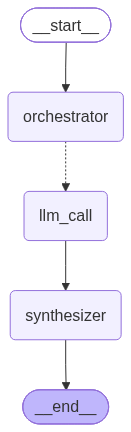

In [25]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Creating the StateGraph
orchestrator_worker_builder = StateGraph(State)

### Adding the Graph Nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

### Adding the Graph Edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

### Compiling the Workflow
orchestrator_worker = orchestrator_worker_builder.compile()

### Visualizing the Workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

### Running the Orchestrator-Worker Workflow

In [27]:
state = orchestrator_worker.invoke({"topic": "Create a report on Iron Man's life in short"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to Iron Man', description='The story of Tony Stark, the brilliant and wealthy inventor who leads a double life as the armored superhero Iron Man'), Section(name='Early Life and Rise to Fame', description="Tony Stark's early life, his rise to become CEO of Stark Industries, and his initial lifestyle as a billionaire playboy"), Section(name='The Turning Point: Captivity and the First Armor', description='The pivotal moment when Tony Stark was captured and forced to build a bomb, leading to the creation of his first Iron Man suit'), Section(name='Life as a Superhero', description="Tony Stark's journey as a superhero, his role in the Avengers, and his major battles against villains like the Mandarin, Ultron, and Thanos"), Section(name='Personal Relationships and Emotional Depth', description="Tony Stark's personal relationships, including his romance with Pepper Potts, his friendship with Rhodey, and his complicated relationship with hi

# Introduction to Iron Man

Tony Stark is a billionaire entrepreneur and genius inventor who operates under the dual identity of the armored superhero Iron Man. Combining unparalleled technological innovation with substantial wealth, Stark balances corporate leadership with a clandestine role as a protector, utilizing advanced exosuits to address threats that conventional methods cannot resolve.

---

### Early Life and Rise to Fame

Tony Stark’s trajectory from privileged heir to global industrialist was defined by exceptional intellect and corporate ambition. Following his father Howard Stark’s death, Tony assumed leadership of Stark Industries at a young age, rapidly expanding the company’s influence in defense and advanced technology. By the time of his early thirties, he had consolidated control as CEO, establishing himself as a billionaire playboy known for lavish parties, high-profile relationships, and a lifestyle characterized by excess and detachment from the moral complexities of his weapons manufacturing.

---

### The Turning Point: Captivity and the First Armor

Tony Stark’s capture by the Ten Rings marked a critical inflection point in his trajectory. Forced to construct a pulse weapon for his captors, Stark instead utilized the device’s core technology to construct MK I, a rudimentary but functional exosuit. This improvised armor enabled him to breach his captivity, transitioning Stark from a weapons manufacturer to the architect of his own salvation.

---

## Life as a Superhero

*   **Avengers Leadership**: As the founding member and tactical leader of the Avengers, Stark coordinated global defense efforts, transitioning from individual heroism to collaborative team strategy.
*   **Key Confrontations**:
    *   **The Mandarin**: In *Iron Man 3*, Stark faced the Ten Rings and the Mandarin, leading to the dismantling of his armored arsenal and a psychological breakthrough.
    *   **Ultron**: The creation of Ultron in *Avengers: Age of Ultron* resulted in a civil war within the team, culminating in the Battle of Sokovia where Stark sacrificed his initial armor designs to stop his own creation.
    *   **Thanos**: Stark’s final act involved sacrificing his life in *Avengers: Endgame* to execute the snap, defeating Thanos and his army to restore half of the universe’s population.

---

### Personal Relationships and Emotional Depth

Tony Stark's character is defined by the tension between his public persona and intimate connections, which drive his narrative arc:

*   **Romance with Pepper Potts:** Their relationship evolves from a professional strain into a deep emotional anchor. Pepper represents stability and moral clarity, grounding Stark's impulsivity and ultimately motivating his self-sacrifice.
*   **Friendship with James "Rhodey" Rhodes:** This bond serves as Stark's primary external check. Rhodey offers unwavering loyalty and a perspective rooted in duty, contrasting Stark's ego and helping maintain his humanity amid ethical dilemmas.
*   **Relationship with Howard Stark:** A source of profound insecurity, Tony’s complicated dynamic with his absent, demanding father fuels his need for peer recognition and validation. This unresolved grief and fear of inadequacy significantly shape his early defensive behaviors and drive his quest for legacy and control.

---

## The Final Chapter: Snap and Legacy

The Battle of Earth culminated in Tony Stark’s ultimate sacrifice, a decisive act that secured the future of the universe. By using the Infinity Stones to eliminate Thanos and his forces, Stark paid the final price, cementing his legacy as the hero who ended the war.

---

## Legacy and Cultural Impact

Tony Stark has fundamentally reshaped the superhero genre, shifting the archetype from stoic moralists to witty, flawed innovators. His influence extends beyond Marvel's internal narrative, popularizing the "tech-bro" anti-hero and driving the commercial success of the Marvel Cinematic Universe. As a cultural symbol, Stark embodies the duality of modern capitalism—brilliant yet arrogant, destructive yet redemptive. His evolution from a weapons manufacturer to a self-sacrificing hero has cemented his status as a defining figure in both comic book history and contemporary film, influencing storytelling tropes regarding identity, responsibility, and the human cost of progress.